In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats


seed = 42
np.random.seed(seed)

In [2]:
# Data

FILEPATH = '.\\femminicidi 2024.xlsx'
df = pd.read_excel(FILEPATH, header=0)


print("Righe: " + str(df.shape[0]) + " - Colonne: " + str(df.shape[1]))

Righe: 112 - Colonne: 34


In [3]:
df = df[df['Tipo'] == 'omicidio']
df = df[df['Relazione con la persona uccisa'] != '-']

print("Righe: " + str(df.shape[0]) + " - Colonne: " + str(df.shape[1]))

Righe: 97 - Colonne: 34


In [4]:
relation_col = df['Relazione con la persona uccisa']

print(relation_col.unique())
print(relation_col.value_counts())

['partner' 'acquaintance' 'family member' 'ex partner' 'stranger']
Relazione con la persona uccisa
partner          50
family member    22
ex partner       12
acquaintance      8
stranger          5
Name: count, dtype: int64


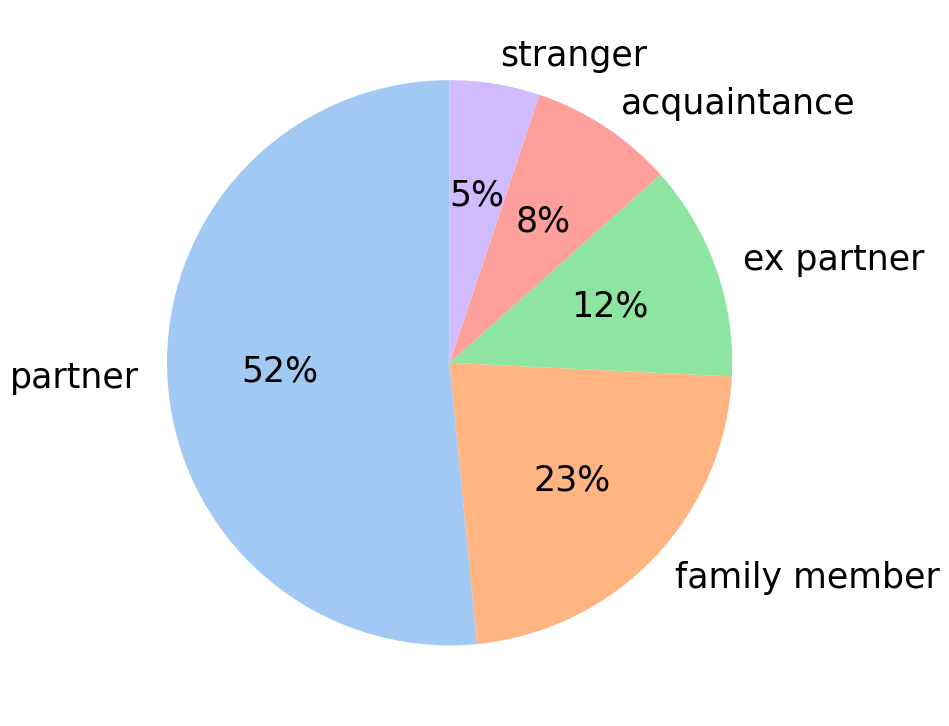

In [6]:
# % Femicides by Relation

# Dati
labels = ['partner', 'family member', 'ex partner', 'acquaintance', 'stranger']
values = [50, 22, 12, 8, 5]

total = sum(values)
center_text = f"{(values[0]/total)*100:.1f}%"

# Grafico a ciambella
fig, ax = plt.subplots(figsize=(9, 8), facecolor='white')
colors = sns.color_palette("pastel", len(values))

wedges, texts, autotexts = ax.pie(
    values,
    colors=colors,
    labels=labels,
    autopct='%1.0f%%',  # percentuali automatiche
    startangle=90,
    textprops={'fontsize': 25},
)

# Testo al centro
#ax.text(0, 0, f'{percent:.1f}%', ha='center', va='center', fontsize=45, color=colors_family[0])

# Legenda
#ax.legend(wedges, labels, title="Relationship", loc="center left", bbox_to_anchor=(1.5, 0.5))

# Titolo e layout
#plt.title('Women Homicides in Family Context (2024)', pad=60, fontsize=22)
plt.tight_layout()
plt.show()

[20.0, 20.0, 20.0, 20.0, 20.0]


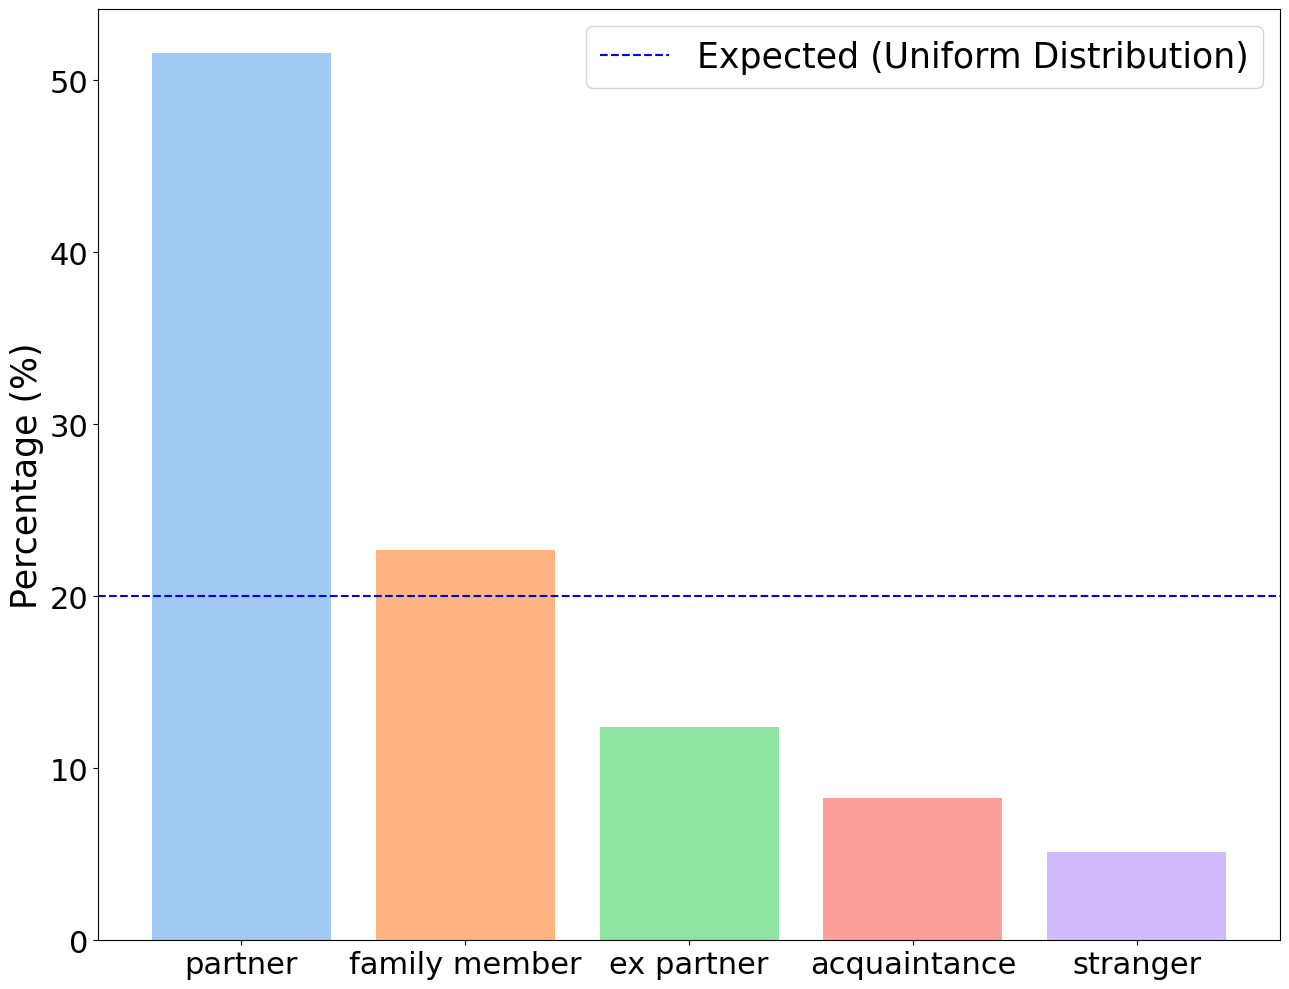

In [20]:
# Dati
categories = ['partner', 'family member', 'ex partner', 'acquaintance', 'stranger']
percentages = [51.55, 22.68, 12.37, 8.25, 5.15]

# Percentuale attesa per distribuzione uniforme (per ogni categoria)
expected_percentage = [100 / len(categories)] * len(categories)
print(expected_percentage)

# Creiamo l'istogramma
fig, ax = plt.subplots(figsize=(13, 10))

# Istogramma delle percentuali reali
ax.bar(categories, percentages, color=colors)

# Linea della distribuzione uniforme (valore atteso)
ax.axhline(20, color='blue', linestyle='--', label='Expected (Uniform Distribution)')

# Aggiungiamo etichette e titolo
ax.set_ylabel('Percentage (%)', fontsize=25)
#ax.set_title('Distribution of Relationships in Femicides (2024) vs. Expected Uniform Distribution')
ax.legend(fontsize=25)

# Mostriamo il grafico
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout()
plt.show()